In [2]:
%matplotlib inline
from pylab import *

In [8]:
from PIL import Image
from glob import glob
from random import choice
from tqdm import tqdm

In [4]:
import process_images_hdf5 as pi5

In [5]:
def gaussian2d(x,y,x0,y0,sigma):
    r2=(x-x0)**2+(y-y0)**2
    return exp(-r2/2/sigma**2)

def circle(x,y,x0,y0,r):
    r2=(x-x0)**2+(y-y0)**2
    return r2<r**2


from scipy.signal import convolve2d

def randbetween(low,high):
    return rand()*(high-low)+low


In [6]:
def deg2pixel(D):
    # the bbsk images are angular size 60 degrees x 40 degrees
    # the raw images are resized so that 
    #   5.5 pixels ~ 0.5 degrees (cat retina)  - default

    P=D/.5*5.5
    return P

def pixel2deg(P):
    D=P/5.5*0.5
    return D

In [7]:
def make_mask(fsig=35,g=None):
    # original size 600x800
    # logged dog is 495 x 660 (old version of masks)
    # the bbsk images are angular size 60 degrees x 40 degrees
    # the raw images are resized so that 
    #   5.5 pixels ~ 0.5 degrees (cat retina)  - default
    
    mx,my=800,600
    x,y=meshgrid(arange(mx),arange(my))
    
    if g is None:
        g=0


        blob_deg_min=3
        blob_deg_max=14
        for i in range(10):
            g=g+circle(x,y,rand()*mx,rand()*my,randbetween(deg2pixel(blob_deg_min),deg2pixel(blob_deg_max)))

        #    g=g+gaussian2d(x,y,rand()*mx,rand()*my,randbetween(deg2pixel(blob_deg_min),deg2pixel(blob_deg_max)))>.5
        g=g>0


    f=gaussian2d(x,y,mx//2,my//2,fsig)
    f=f[(my//2-200):(my//2+200),(mx//2-200):(mx//2+200)]

    #f=f[(my//2-3*fsig):(my//2+3*fsig),(mx//2-3*fsig):(mx//2+3*fsig)]
    
    res=convolve2d(g,f,mode='same')
    res=res/res.max()
    
    return res

(20, 600, 800)

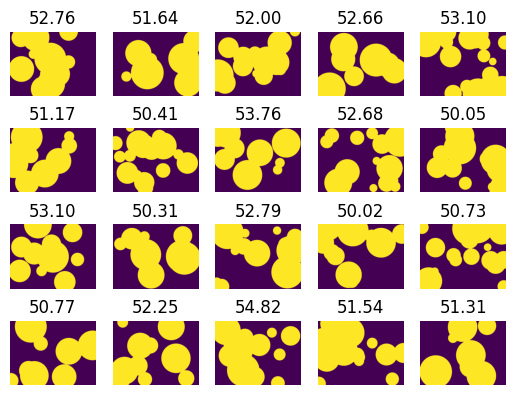

In [16]:
mx,my=800,600
x,y=meshgrid(arange(mx),arange(my))

gs=[]
for k in range(20):
    g=0


    blob_deg_min=3
    blob_deg_max=14
    percentage_covered=0
    while percentage_covered<50:
        g=g+circle(x,y,rand()*mx,rand()*my,randbetween(deg2pixel(blob_deg_min),deg2pixel(blob_deg_max)))
        g=g>0
        percentage_covered=g.sum()/prod(g.shape)*100
    #    g=g+gaussian2d(x,y,rand()*mx,rand()*my,randbetween(deg2pixel(blob_deg_min),deg2pixel(blob_deg_max)))>.5

    
    gs.append(g)
    
    subplot(4,5,k+1)
    imshow(g,extent=[0,pixel2deg(mx),0,pixel2deg(my)])
    axis('off')
    title(f'{percentage_covered:.2f}')
    # xlabel('degrees')
    # ylabel('degrees')


garr=asarray(gs)
np.save('bblais-masks-20250420/2025-04-20-blobs.npy',garr)
garr.shape

0it [00:00, ?it/s]
  5%|██▏                                        | 1/20 [01:45<33:30, 105.82s/it]

bblais-masks-20250420/2025-04-20-A-A-fsig10.png
bblais-masks-20250420/2025-04-20-A-F-fsig10.png



 10%|████▎                                      | 2/20 [03:31<31:46, 105.93s/it]

bblais-masks-20250420/2025-04-20-B-A-fsig10.png
bblais-masks-20250420/2025-04-20-B-F-fsig10.png



 15%|██████▍                                    | 3/20 [05:17<29:59, 105.84s/it]

...

bblais-masks-20250420/2025-04-20-R-A-fsig90.png
bblais-masks-20250420/2025-04-20-R-F-fsig90.png



 95%|███████████████████████████████████████▉  | 19/20 [35:38<01:51, 111.90s/it]

bblais-masks-20250420/2025-04-20-S-A-fsig90.png
bblais-masks-20250420/2025-04-20-S-F-fsig90.png



100%|██████████████████████████████████████████| 20/20 [37:31<00:00, 112.55s/it]
5it [3:04:31, 2214.33s/it]

bblais-masks-20250420/2025-04-20-T-A-fsig90.png
bblais-masks-20250420/2025-04-20-T-F-fsig90.png


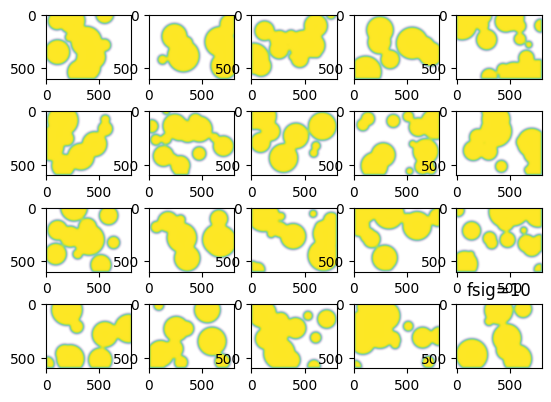

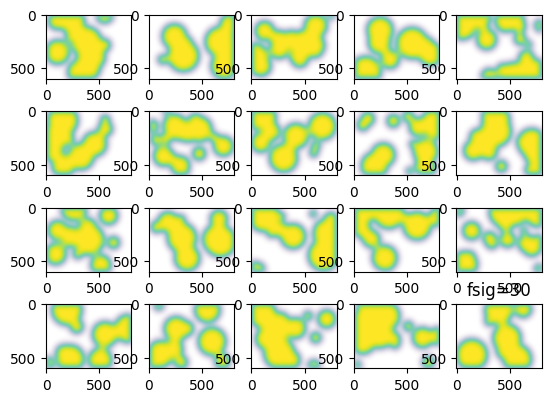

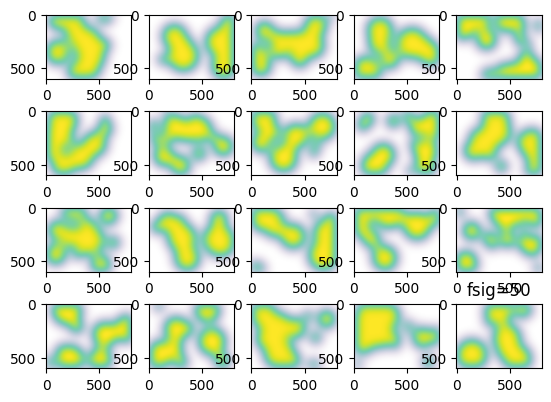

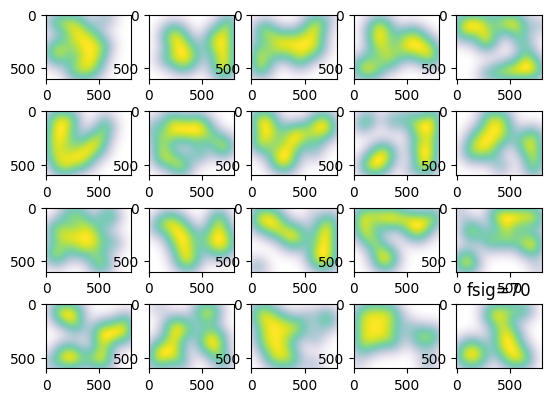

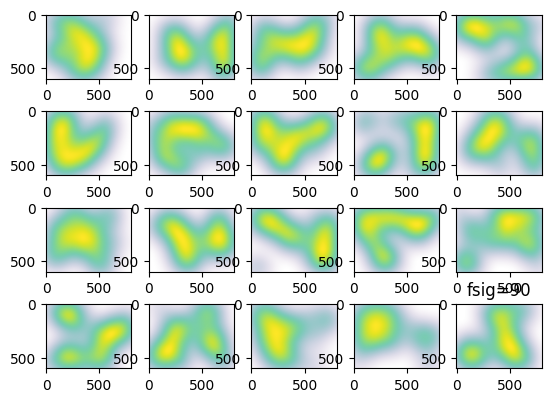

In [18]:
count=1
for f,fsig in tqdm(enumerate([10,30,50,70,90])):
    figure()
    for k in tqdm(list(range(20))):
        res=make_mask(fsig,gs[k])

        AA=np.uint8(cm.viridis(res)*255)
        AA[:,:,3]=res*255

        FF=np.uint8(cm.viridis(1-res)*255)
        FF[:,:,3]=(1-res)*255

        im=Image.fromarray(AA)    
        fname='bblais-masks-20250420/2025-04-20-%c-A-fsig%2d.png' % (k+65,fsig)
        im.save(fname)
        print(fname)

        subplot(4,5,k+1)
        imshow(im)

        im=Image.fromarray(FF)    
        fname='bblais-masks-20250420/2025-04-20-%c-F-fsig%2d.png' % (k+65,fsig)
        im.save(fname)
        print(fname)

        # subplot(5,5,count)
        # imshow(im)
    
        count+=1
    title(f'fsig={fsig}')